In [69]:
import os
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from skimage.feature import hog,local_binary_pattern
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,learning_curve
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier,ExtraTreesClassifier,RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB




In [70]:
!pip install xgboost

In [71]:
from xgboost import XGBClassifier

In [72]:
zip_path='/content/archive (1).zip'
extract_path='/content/original_dataset'
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall(extract_path)
print("zip extracted successfully")

zip extracted successfully


In [73]:
print(os.listdir(extract_path))

['fruit-dataset']


In [74]:
print(os.listdir(extract_path+"/fruit-dataset"))

['apple', 'orange']


In [75]:
print(os.listdir(extract_path+"/fruit-dataset"+"/apple"))

['299.jpeg', '279.jpeg', '111.jpeg', '003.jpeg', '217.jpeg', '277.jpeg', '230.jpeg', '323.jpeg', '093.jpeg', '098.jpeg', '260.jpeg', '370.jpeg', '053.jpeg', '337.jpeg', '106.jpeg', '183.jpeg', '254.jpeg', '244.jpeg', '160.jpeg', '130.jpeg', '374.jpeg', '207.jpeg', '296.jpeg', '118.jpeg', '152.jpeg', '027.jpeg', '095.jpeg', '075.jpeg', '051.jpeg', '088.jpeg', '039.jpeg', '060.jpeg', '064.jpeg', '295.jpeg', '178.jpeg', '090.jpeg', '094.jpeg', '192.jpeg', '365.jpeg', '041.jpeg', '042.jpeg', '220.jpeg', '050.jpeg', '036.jpeg', '002.jpeg', '284.jpeg', '187.jpeg', '157.jpeg', '232.jpeg', '271.jpeg', '007.jpeg', '251.jpeg', '214.jpeg', '368.jpeg', '397.jpeg', '275.jpeg', '366.jpeg', '067.jpeg', '038.jpeg', '092.jpeg', '018.jpeg', '005.jpeg', '185.jpeg', '197.jpeg', '314.jpeg', '328.jpeg', '361.jpeg', '227.jpeg', '159.jpeg', '161.jpeg', '044.jpeg', '360.jpeg', '381.jpeg', '165.jpeg', '142.jpeg', '089.jpeg', '398.jpeg', '167.jpeg', '013.jpeg', '342.jpeg', '394.jpeg', '076.jpeg', '252.jpeg', '24

In [76]:
print(os.listdir(extract_path+"/fruit-dataset"+"/orange"))

['299.jpeg', '279.jpeg', '111.jpeg', '003.jpeg', '217.jpeg', '277.jpeg', '230.jpeg', '323.jpeg', '093.jpeg', '098.jpeg', '260.jpeg', '370.jpeg', '053.jpeg', '127.jpeg', '337.jpeg', '106.jpeg', '183.jpeg', '254.jpeg', '244.jpeg', '160.jpeg', '130.jpeg', '374.jpeg', '207.jpeg', '296.jpeg', '118.jpeg', '152.jpeg', '027.jpeg', '095.jpeg', '075.jpeg', '051.jpeg', '088.jpeg', '039.jpeg', '060.jpeg', '064.jpeg', '295.jpeg', '178.jpeg', '090.jpeg', '094.jpeg', '192.jpeg', '365.jpeg', '041.jpeg', '042.jpeg', '220.jpeg', '050.jpeg', '036.jpeg', '002.jpeg', '284.jpeg', '187.jpeg', '157.jpeg', '232.jpeg', '271.jpeg', '007.jpeg', '251.jpeg', '214.jpeg', '368.jpeg', '397.jpeg', '275.jpeg', '366.jpeg', '067.jpeg', '038.jpeg', '092.jpeg', '018.jpeg', '005.jpeg', '185.jpeg', '197.jpeg', '314.jpeg', '328.jpeg', '361.jpeg', '227.jpeg', '159.jpeg', '161.jpeg', '044.jpeg', '360.jpeg', '381.jpeg', '165.jpeg', '142.jpeg', '089.jpeg', '398.jpeg', '167.jpeg', '013.jpeg', '342.jpeg', '394.jpeg', '076.jpeg', '25

In [77]:
def preprocess(img):
  img=cv2.resize(img,(128,128))
  gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
  return img,hsv,gray


In [78]:
def feature_extraction(img,hsv,gray):
  features=[]
  #HSV the histogram
  hist=cv2.calcHist([hsv],[0],None,[32],[0,180])
  hist=hist.astype("float32")
  hist/=((hist.sum())+1e-6)
  features.extend(hist.flatten())
  #LOCAL binary pattern
  lbp=local_binary_pattern(gray,P=8,R=1,method='uniform')
  lbp_hist,_=np.histogram(lbp.ravel(),bins=10,range=(0,10))
  lbp_hist=lbp_hist.astype("float32")
  lbp_hist/=((lbp_hist.sum())+1e-6)
  features.extend(lbp_hist)
  #shape the features
  edges=cv2.Canny(gray,100,200)
  contours,_=cv2.findContours(edges,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
  area=sum(cv2.contourArea(c) for c in contours)
  perimeter=sum(cv2.arcLength(c,True) for c in contours)
  #hard safety guards
  area=np.clip(area,0,1e5)
  perimeter=np.clip(perimeter,0,1e4)
  circularity=(4*np.pi*area)/(perimeter**2+1e-6)
  features.extend([area,perimeter,circularity])
  #HOG
  # hog_features = hog(gray,orientations=9,pixels_per_cell=(8,8),cells_per_block=(2,2),visualize=False,feature_vector=True)
  # hog_features = hog_features.astype("float32")
  # features.extend(hog_features)
  return np.array(features,dtype="float32")

In [103]:
def get_augmentations(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return [
        img,cv2.resize(img, (128, 128),interpolation=cv2.INTER_LINEAR),
        cv2.flip(img, 0),
        cv2.bilateralFilter(img, 9, 75, 75)
    ]

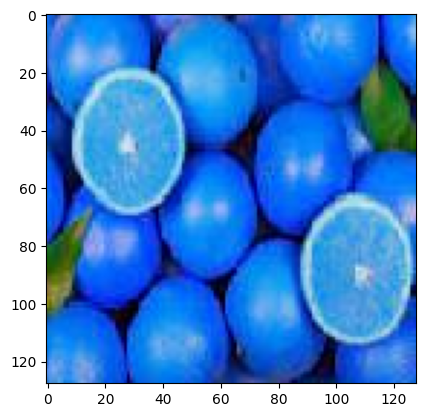

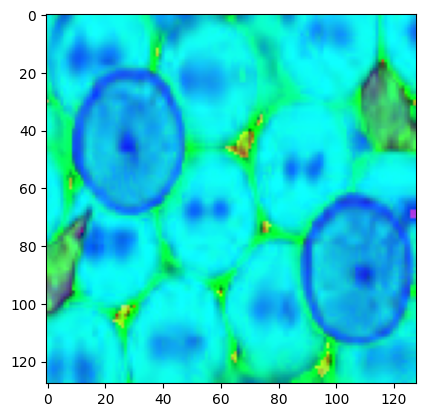

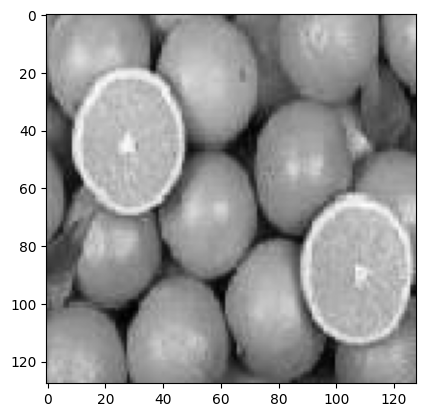

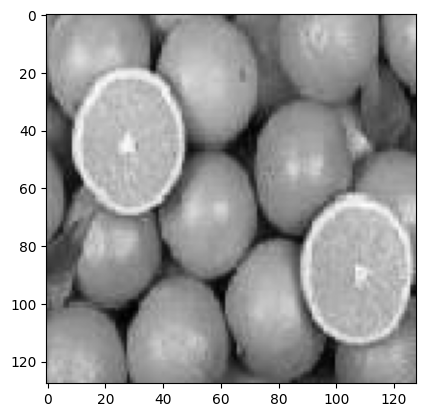

In [104]:
def show_preprocessing_demo(img_path):
  img=cv2.imread(img_path)
  img,hsv,gray=preprocess(img)
  plt.imshow(img)
  plt.show()
  plt.imshow(hsv)
  plt.show()
  plt.imshow(gray,cmap='gray')
  plt.show()
  plt.imshow(gray,cmap='gray')
  plt.show()
show_preprocessing_demo('/content/original_dataset/fruit-dataset/orange/004.jpeg')


In [107]:
x=[]
y=[]

base_path='/content/original_dataset/fruit-dataset/apple'

num=0
for filename in os.listdir(base_path):
    try:
        path=os.path.join(base_path,filename)
        img=cv2.imread(path)
        if img is None:
            print(f"Warning: Could not load image {path}",end='\r')
            continue

        augmented_images = get_augmentations(img)
        for aug_img in augmented_images:
            processed_img,hsv,gray=preprocess(aug_img)
            features=feature_extraction(processed_img,hsv,gray)
            x.append(features)
            y.append(0)
        print("Images Done",num,end='\r')
        num+=1
    except Exception as e:
        print(e,end='\r')

print()
num=0

base_path='/content/original_dataset/fruit-dataset/orange'

for filename in os.listdir(base_path):
    try:
        path=os.path.join(base_path,filename)
        img=cv2.imread(path)
        if img is None:
            print(f"Warning: Could not load image {path}",end='\r')
            continue

        augmented_images = get_augmentations(img)
        for aug_img in augmented_images:
            processed_img,hsv,gray=preprocess(aug_img)
            features=feature_extraction(processed_img,hsv,gray)
            x.append(features)
            y.append(1) # Corrected label for orange
        print("Images Done",num,end='\r')
        num+=1
    except Exception as e:
        print(e,end='\r')


Images Done 395


In [108]:
x=np.array(x,dtype='float32')
y=np.array(y)
smote=SMOTE(random_state=42)
x_resample,y_resample=smote.fit_resample(x,y)

In [109]:
import sklearn
print(sklearn.__version__)

1.6.1


In [110]:
x_train,x_test,y_train,y_test=train_test_split(x_resample,y_resample,test_size=0.2,random_state=42,stratify=y_resample)

In [111]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [112]:
clf=RandomForestClassifier(n_estimators=100,random_state=42)
clf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

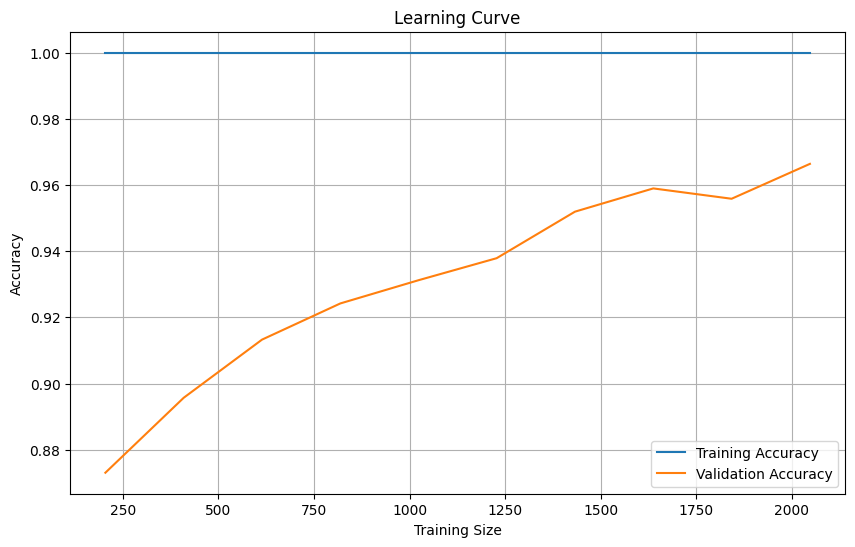

In [113]:
train_sizes, train_scores, test_scores = learning_curve(
    clf,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label='Training Accuracy')

plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel('Training Size')

plt.ylabel('Accuracy')

plt.title('Learning Curve')

plt.legend()

plt.grid()

plt.show()

In [114]:
y_pred=clf.predict(x_test)
classes=["apple","orange"]
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred,target_names=classes))


0.9765625
              precision    recall  f1-score   support

       apple       0.98      0.97      0.98       320
      orange       0.98      0.98      0.98       320

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



In [115]:
predicted_labels=[classes[i] for i in y_pred]
actual_labels=[classes[i] for i in y_test]

In [116]:
results=pd.DataFrame({
    'Actual':actual_labels,
    'Predicted':predicted_labels})


In [117]:
results.to_csv('submission.csv',index=False)

In [118]:
results.head()

,Actual,Predicted
0,apple,apple
1,apple,apple
2,orange,orange
3,apple,apple
4,orange,orange


In [96]:
import requests
url='https://raw.githubusercontent.com/Dhruv-coder797/cvese/main/final3.ipynb'
content=requests.get(url).json()
for i,cell in enumerate(content["cells"]):
  print(" ".join(cell['source']))

# STEP 2: Import libraries
 import os
 import zipfile
 import cv2
 import numpy as np
 import matplotlib.pyplot as plt
 import pandas as pd
 from skimage.feature import local_binary_pattern
 from sklearn.model_selection import train_test_split, learning_curve
 from sklearn.preprocessing import StandardScaler
 from sklearn.pipeline import Pipeline
 from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
 from sklearn.neighbors import KNeighborsClassifier
 from sklearn.svm import SVC
 from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
 from sklearn.linear_model import LogisticRegression
 from sklearn.tree import DecisionTreeClassifier
 from sklearn.naive_bayes import GaussianNB
 from sklearn.pipeline import Pipeline
 from imblearn.over_sampling import SMOTE

 zip_path = "/content/archive (1).zip"
 extract_path = "/content/extracted_dataset"
 with zipfile.ZipFile(zip_path, 'r') as zip_ref:
     zip_ref.extracta